##  Regresión Multivariada
### Selección de variables predictoras

Dr. Hugo García Tecocoatzi

In [1]:
#  Importar bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.feature_selection import f_regression, SelectKBest

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

Vamos a generar datos sintéticos para la actividad:

In [2]:

#  Simulamos un problema de bienes raíces
np.random.seed(42)
n = 200

# Variables predictoras
Tamaño = np.random.randn(n) * 10 + 50           # Tamaño en m²
Habitaciones = Tamaño + np.random.randn(n) * 3  # Número de habitaciones (correlacionado)
Antigüedad = np.random.randn(n) * 5 + 20        # Antigüedad en años
Ubicación = np.random.randn(n) * 3 + 5          # Calidad de ubicación (1-10)

# Variable respuesta (precio)
Precio = 500 + 25*Tamaño + 15*Habitaciones - 8*Antigüedad + 30*Ubicación + np.random.randn(n)*50

# Crear DataFrame
df = pd.DataFrame({
    'Tamaño': Tamaño,
    'Habitaciones': Habitaciones,
    'Antigüedad': Antigüedad,
    'Ubicación': Ubicación,
    'Precio': Precio
})


print(f"Forma del dataset: {df.shape}")
print("\nPrimeras 5 filas:")
df.head()

Forma del dataset: (200, 5)

Primeras 5 filas:


,Tamaño,Habitaciones,Antigüedad,Ubicación,Precio
0,54.967142,56.040504,12.027862,7.270966,2883.606365
1,48.617357,50.299711,17.003125,2.233504,2375.107469
2,56.476885,59.726039,20.026218,7.608818,2880.673545
3,65.230299,68.391705,20.234903,9.066914,3243.647454
4,47.658466,43.525458,17.749673,6.240305,2367.830477


In [3]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS\n")
print(df.describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS

       Tamaño  Habitaciones  Antigüedad  Ubicación   Precio
count  200.00        200.00      200.00     200.00   200.00
mean    49.59         49.85       19.57       5.03  2488.20
std      9.31         10.03        4.97       3.06   403.41
min     23.80         20.86        7.64      -3.09  1203.80
25%     42.95         43.03       16.03       2.88  2199.68
50%     49.96         50.35       19.61       5.07  2494.96
75%     55.01         55.75       22.86       7.06  2744.40
max     77.20         77.07       35.39      12.90  3663.00


In [4]:
# Matriz de correlación detallada
print("\nMATRIZ DE CORRELACIÓN\n")
print(df.corr().round(3))


MATRIZ DE CORRELACIÓN

              Tamaño  Habitaciones  Antigüedad  Ubicación  Precio
Tamaño         1.000         0.956      -0.134      0.065   0.958
Habitaciones   0.956         1.000      -0.134      0.031   0.936
Antigüedad    -0.134        -0.134       1.000      0.106  -0.199
Ubicación      0.065         0.031       0.106      1.000   0.287
Precio         0.958         0.936      -0.199      0.287   1.000


### Preguntas

1. ¿Qué variables tienen mayor correlación con el Precio?

   Tamaño con 0.988 (una correlación positiva muy fuerte)
   Habitaciones con 0.936 (una correlación positiva muy fuerte)
   
2. ¿Hay variables altamente correlacionadas entre sí? ¿Cuáles?

    Tamaño y Habitaciones con una correlación positiva de 0.956
    Tamaño y Precio con una correlación positiva con 0.958
    Habitaciones y Precio con una correlación positiva de 0.936

3. ¿Cómo crees que afecta cada variable al precio?"

    Tamaño (0.958) -> A mayor tamaño de la propiedad, mayor es precio.

    Habitaciones (0.936) -> Mayor númerco de habitaciones, mayor será su precio.

    Ubicación  (0.287) -> Una relación positiva muy débil, su impacto lineal individual es menor del que podría esperarse intuitivamente en un mercado inmobiliario típico.

    Antigüedad (-0.119) -> Una relación negativa muy débil, esto muestra una leve depreciación por el paso del tiempo.
    


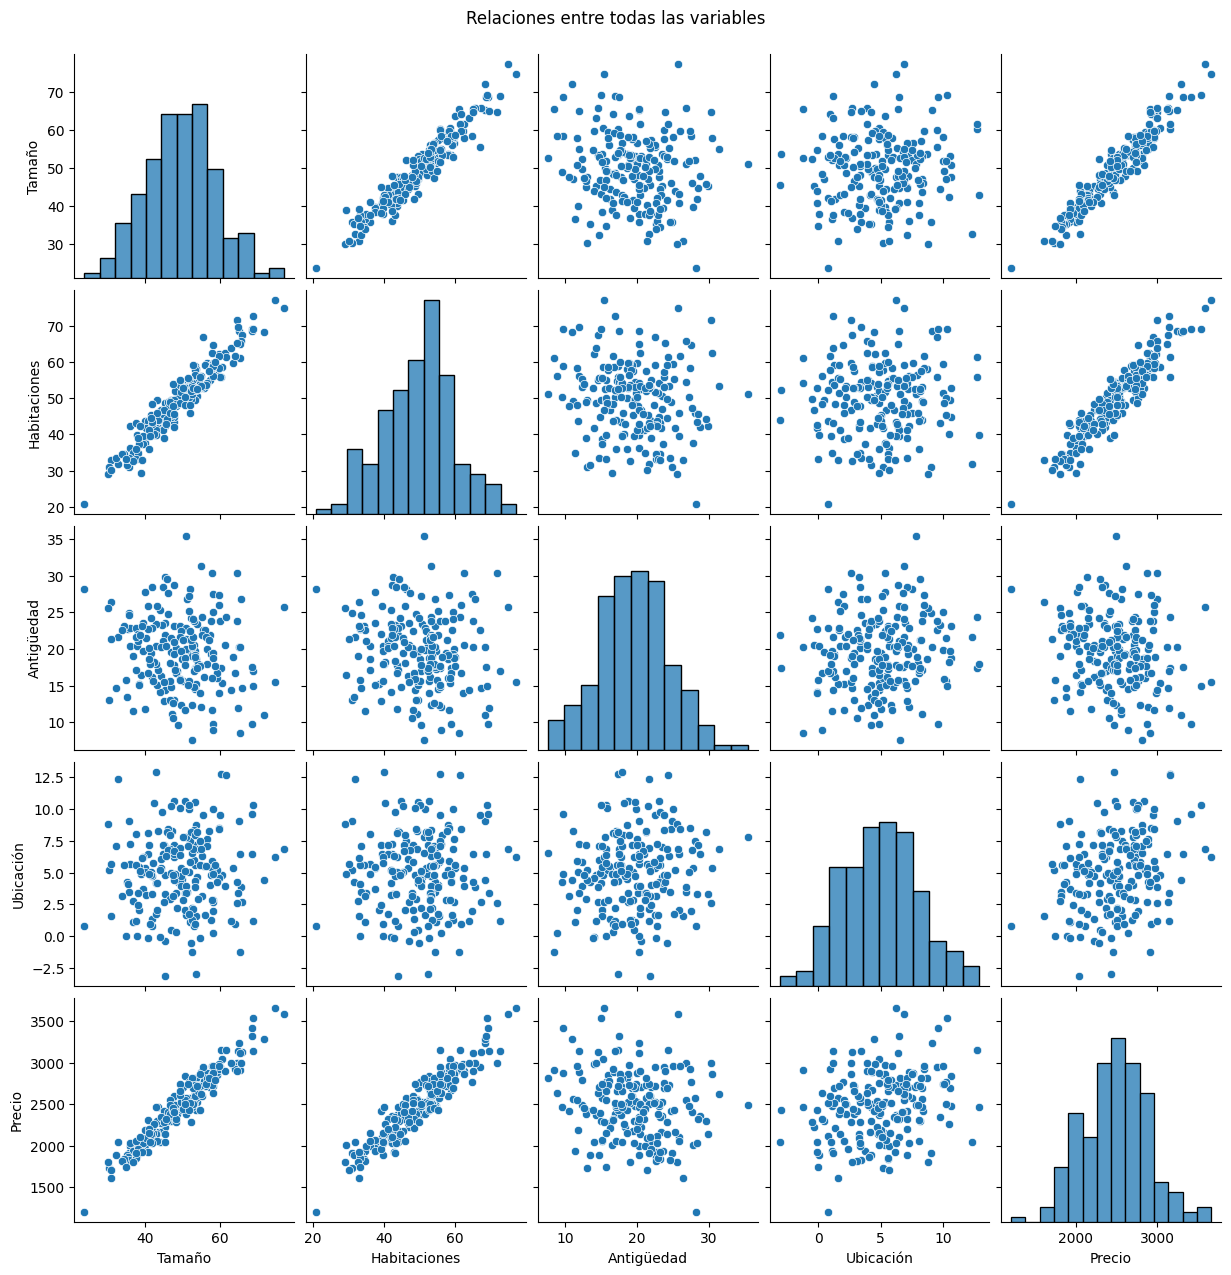

In [5]:
# Pairplot de variables
sns.pairplot(df)
plt.suptitle('Relaciones entre todas las variables', y=1.02)
plt.show()

In [6]:
#  Dividir datos en entrenamiento y prueba
X = df.drop('Precio', axis=1)
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")

Tamaño de entrenamiento: 140 muestras
Tamaño de prueba: 60 muestras


In [7]:
# Entrenar modelo de regresión lineal con todas las variables
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
print("=== COEFICIENTES DEL MODELO ===\n")
print(coeficientes)
print(f"\nIntercept (término constante): {modelo.intercept_:.4f}")

=== COEFICIENTES DEL MODELO ===

       Variable  Coeficiente
0        Tamaño    28.191932
1  Habitaciones    12.110154
2    Antigüedad    -7.294327
3     Ubicación    32.566862

Intercept (término constante): 467.3919


In [8]:
# Evaluar modelo completo
y_pred = modelo.predict(X_test)

MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = metrics.r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN ===\n")
print(f"Error Absoluto Medio (MAE): {MAE:.4f}")
print(f"Error Cuadrático Medio (MSE): {MSE:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {RMSE:.4f}")
print(f"R² (Coeficiente de Determinación): {R2:.4f}")

=== MÉTRICAS DE EVALUACIÓN ===

Error Absoluto Medio (MAE): 39.1850
Error Cuadrático Medio (MSE): 2274.3596
Raíz del Error Cuadrático Medio (RMSE): 47.6902
R² (Coeficiente de Determinación): 0.9828


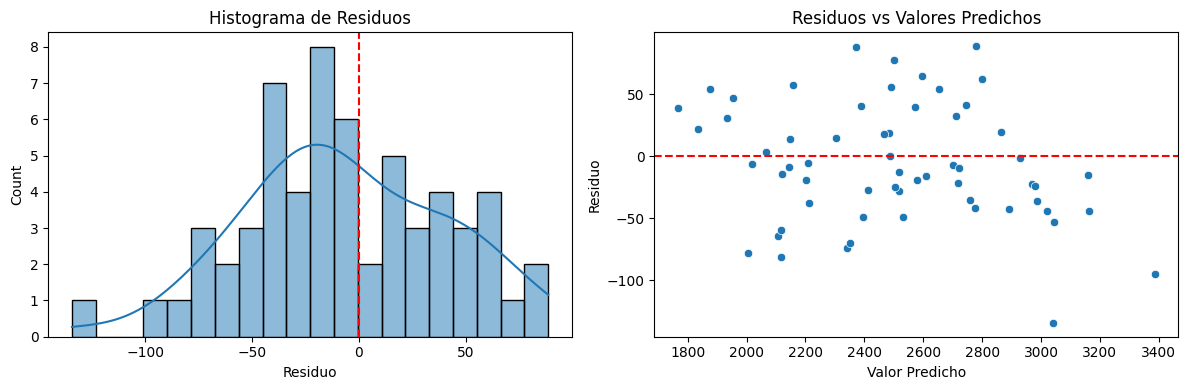

Media de residuos: -6.4355
Desviación estándar de residuos: 47.6528


In [9]:
# Análisis de residuos
residuos = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, bins=20)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Histograma de Residuos')
plt.xlabel('Residuo')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Valores Predichos')
plt.xlabel('Valor Predicho')
plt.ylabel('Residuo')

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")

In [10]:
# Cálculo del VIF (Factor de Inflación de la Varianza)
X_constant = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_constant.values, i)
                   for i in range(X_constant.shape[1])]

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===\n")
print(vif_data)
print("\n Recuerda:")
print("- VIF > 5: indica alta multicolinealidad")
print("- VIF > 10: indica multicolinealidad severa")

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===

       Variable        VIF
0         const   1.000000
1        Tamaño  11.780300
2  Habitaciones  11.727624
3    Antigüedad   1.032297
4     Ubicación   1.029735

 Recuerda:
- VIF > 5: indica alta multicolinealidad
- VIF > 10: indica multicolinealidad severa


In [11]:
#  Selección hacia adelante (Forward Selection)
def forward_selection(X, y, threshold=0.05):
    """
    Selección de variables hacia adelante basada en p-valor
    """
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)

        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]

        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

        if not changed:
            break

    return included

print("=== SELECCIÓN HACIA ADELANTE ===\n")
variables_seleccionadas = forward_selection(X, y)
print(f"Variables seleccionadas: {variables_seleccionadas}")

=== SELECCIÓN HACIA ADELANTE ===

Variables seleccionadas: ['Tamaño', 'Ubicación', 'Antigüedad', 'Habitaciones']


In [12]:
# Comparación de modelos con diferentes variables
print("=== COMPARACIÓN DE MODELOS ===\n")

combinaciones = [
    ['Tamaño'],
    ['Tamaño', 'Habitaciones'],
    ['Tamaño', 'Habitaciones', 'Antigüedad'],
    ['Tamaño', 'Habitaciones', 'Antigüedad', 'Ubicación'],
    variables_seleccionadas
]

nombres_combinaciones = [
    'Modelo 1: Tamaño',
    'Modelo 2: Tamaño + Habitaciones',
    'Modelo 3: Tamaño + Habitaciones + Antigüedad',
    'Modelo 4: Modelo completo',
    'Modelo 5: Variables seleccionadas (Forward)'
]

for nombre, vars_list in zip(nombres_combinaciones, combinaciones):
    X_sel = sm.add_constant(X[vars_list])
    model = sm.OLS(y, X_sel).fit()

    print(f"📊 {nombre}")
    print(f"  Variables: {vars_list}")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  R² ajustado = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  BIC = {model.bic:.2f}")
    print()

=== COMPARACIÓN DE MODELOS ===

📊 Modelo 1: Tamaño
  Variables: ['Tamaño']
  R² = 0.9178
  R² ajustado = 0.9174
  AIC = 2470.82
  BIC = 2477.41

📊 Modelo 2: Tamaño + Habitaciones
  Variables: ['Tamaño', 'Habitaciones']
  R² = 0.9228
  R² ajustado = 0.9220
  AIC = 2460.37
  BIC = 2470.26

📊 Modelo 3: Tamaño + Habitaciones + Antigüedad
  Variables: ['Tamaño', 'Habitaciones', 'Antigüedad']
  R² = 0.9276
  R² ajustado = 0.9265
  AIC = 2449.43
  BIC = 2462.63

📊 Modelo 4: Modelo completo
  Variables: ['Tamaño', 'Habitaciones', 'Antigüedad', 'Ubicación']
  R² = 0.9866
  R² ajustado = 0.9863
  AIC = 2113.96
  BIC = 2130.45

📊 Modelo 5: Variables seleccionadas (Forward)
  Variables: ['Tamaño', 'Ubicación', 'Antigüedad', 'Habitaciones']
  R² = 0.9866
  R² ajustado = 0.9863
  AIC = 2113.96
  BIC = 2130.45



In [13]:
# Análisis detallado del mejor modelo
print("=== MEJOR MODELO SEGÚN FORWARD SELECTION ===\n")

X_sel = sm.add_constant(X[variables_seleccionadas])
modelo_final = sm.OLS(y, X_sel).fit()
print(modelo_final.summary())

=== MEJOR MODELO SEGÚN FORWARD SELECTION ===

                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     3591.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          2.30e-181
Time:                        14:36:03   Log-Likelihood:                -1052.0
No. Observations:                 200   AIC:                             2114.
Df Residuals:                     195   BIC:                             2130.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
co

In [14]:
# Evaluación del mejor modelo en test
X_train_sel = X_train[variables_seleccionadas]
X_test_sel = X_test[variables_seleccionadas]

modelo_sel = LinearRegression()
modelo_sel.fit(X_train_sel, y_train)

y_pred_sel = modelo_sel.predict(X_test_sel)

MAE_sel = metrics.mean_absolute_error(y_test, y_pred_sel)
MSE_sel = metrics.mean_squared_error(y_test, y_pred_sel)
RMSE_sel = np.sqrt(MSE_sel)
R2_sel = metrics.r2_score(y_test, y_pred_sel)

print("=== COMPARACIÓN DE RENDIMIENTO ===\n")
print("Modelo Completo vs Modelo Seleccionado:")

print(f"\nModelo Completo (todas las variables):")
print(f"  MAE: {MAE:.4f}")
print(f"  RMSE: {RMSE:.4f}")
print(f"  R²: {R2:.4f}")

print(f"\nModelo Seleccionado ({variables_seleccionadas}):")
print(f"  MAE: {MAE_sel:.4f}")
print(f"  RMSE: {RMSE_sel:.4f}")
print(f"  R²: {R2_sel:.4f}")

=== COMPARACIÓN DE RENDIMIENTO ===

Modelo Completo vs Modelo Seleccionado:

Modelo Completo (todas las variables):
  MAE: 39.1850
  RMSE: 47.6902
  R²: 0.9828

Modelo Seleccionado (['Tamaño', 'Ubicación', 'Antigüedad', 'Habitaciones']):
  MAE: 39.1850
  RMSE: 47.6902
  R²: 0.9828


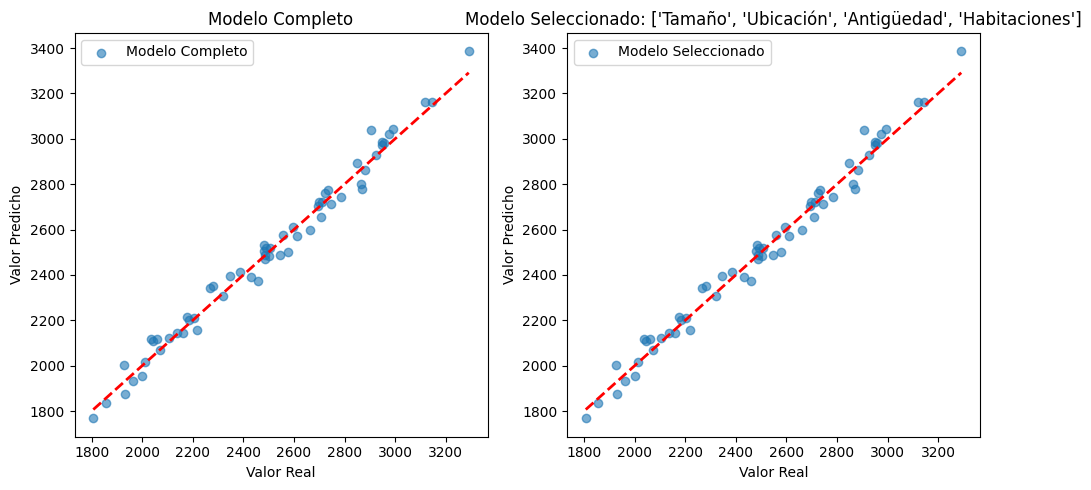

In [15]:
# Visualización del modelo seleccionado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, label='Modelo Completo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Modelo Completo')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sel, alpha=0.6, label='Modelo Seleccionado')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title(f'Modelo Seleccionado: {variables_seleccionadas}')
plt.legend()

plt.tight_layout()
plt.show()

## Actividad Final

Utiliza este notebook para ver qué varibles debes eliminar de la base de datos de Real Estate

In [16]:
data = pd.read_csv('/content/Realestate (1).csv')

In [17]:
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [18]:
#ESTADÍSTICA DESCRIPTIVA
print("ESTADÍSTICAS DESCRIPTIVAS\n")
print(data.describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS

           No  X1 transaction date  X2 house age  \
count  414.00               414.00        414.00   
mean   207.50              2013.15         17.71   
std    119.66                 0.28         11.39   
min      1.00              2012.67          0.00   
25%    104.25              2012.92          9.02   
50%    207.50              2013.17         16.10   
75%    310.75              2013.42         28.15   
max    414.00              2013.58         43.80   

       X3 distance to the nearest MRT station  \
count                                  414.00   
mean                                  1083.89   
std                                   1262.11   
min                                     23.38   
25%                                    289.32   
50%                                    492.23   
75%                                   1454.28   
max                                   6488.02   

       X4 number of convenience stores  X5 latitude  X6 longit

In [19]:
# Matriz de correlación detallada
print("\nMATRIZ DE CORRELACIÓN\n")
print(data.corr().round(3))


MATRIZ DE CORRELACIÓN

                                           No  X1 transaction date  \
No                                      1.000               -0.049   
X1 transaction date                    -0.049                1.000   
X2 house age                           -0.033                0.018   
X3 distance to the nearest MRT station -0.014                0.061   
X4 number of convenience stores        -0.013                0.010   
X5 latitude                            -0.010                0.035   
X6 longitude                           -0.011               -0.041   
Y house price of unit area             -0.029                0.087   

                                        X2 house age  \
No                                            -0.033   
X1 transaction date                            0.018   
X2 house age                                   1.000   
X3 distance to the nearest MRT station         0.026   
X4 number of convenience stores                0.050   
X5 latitu

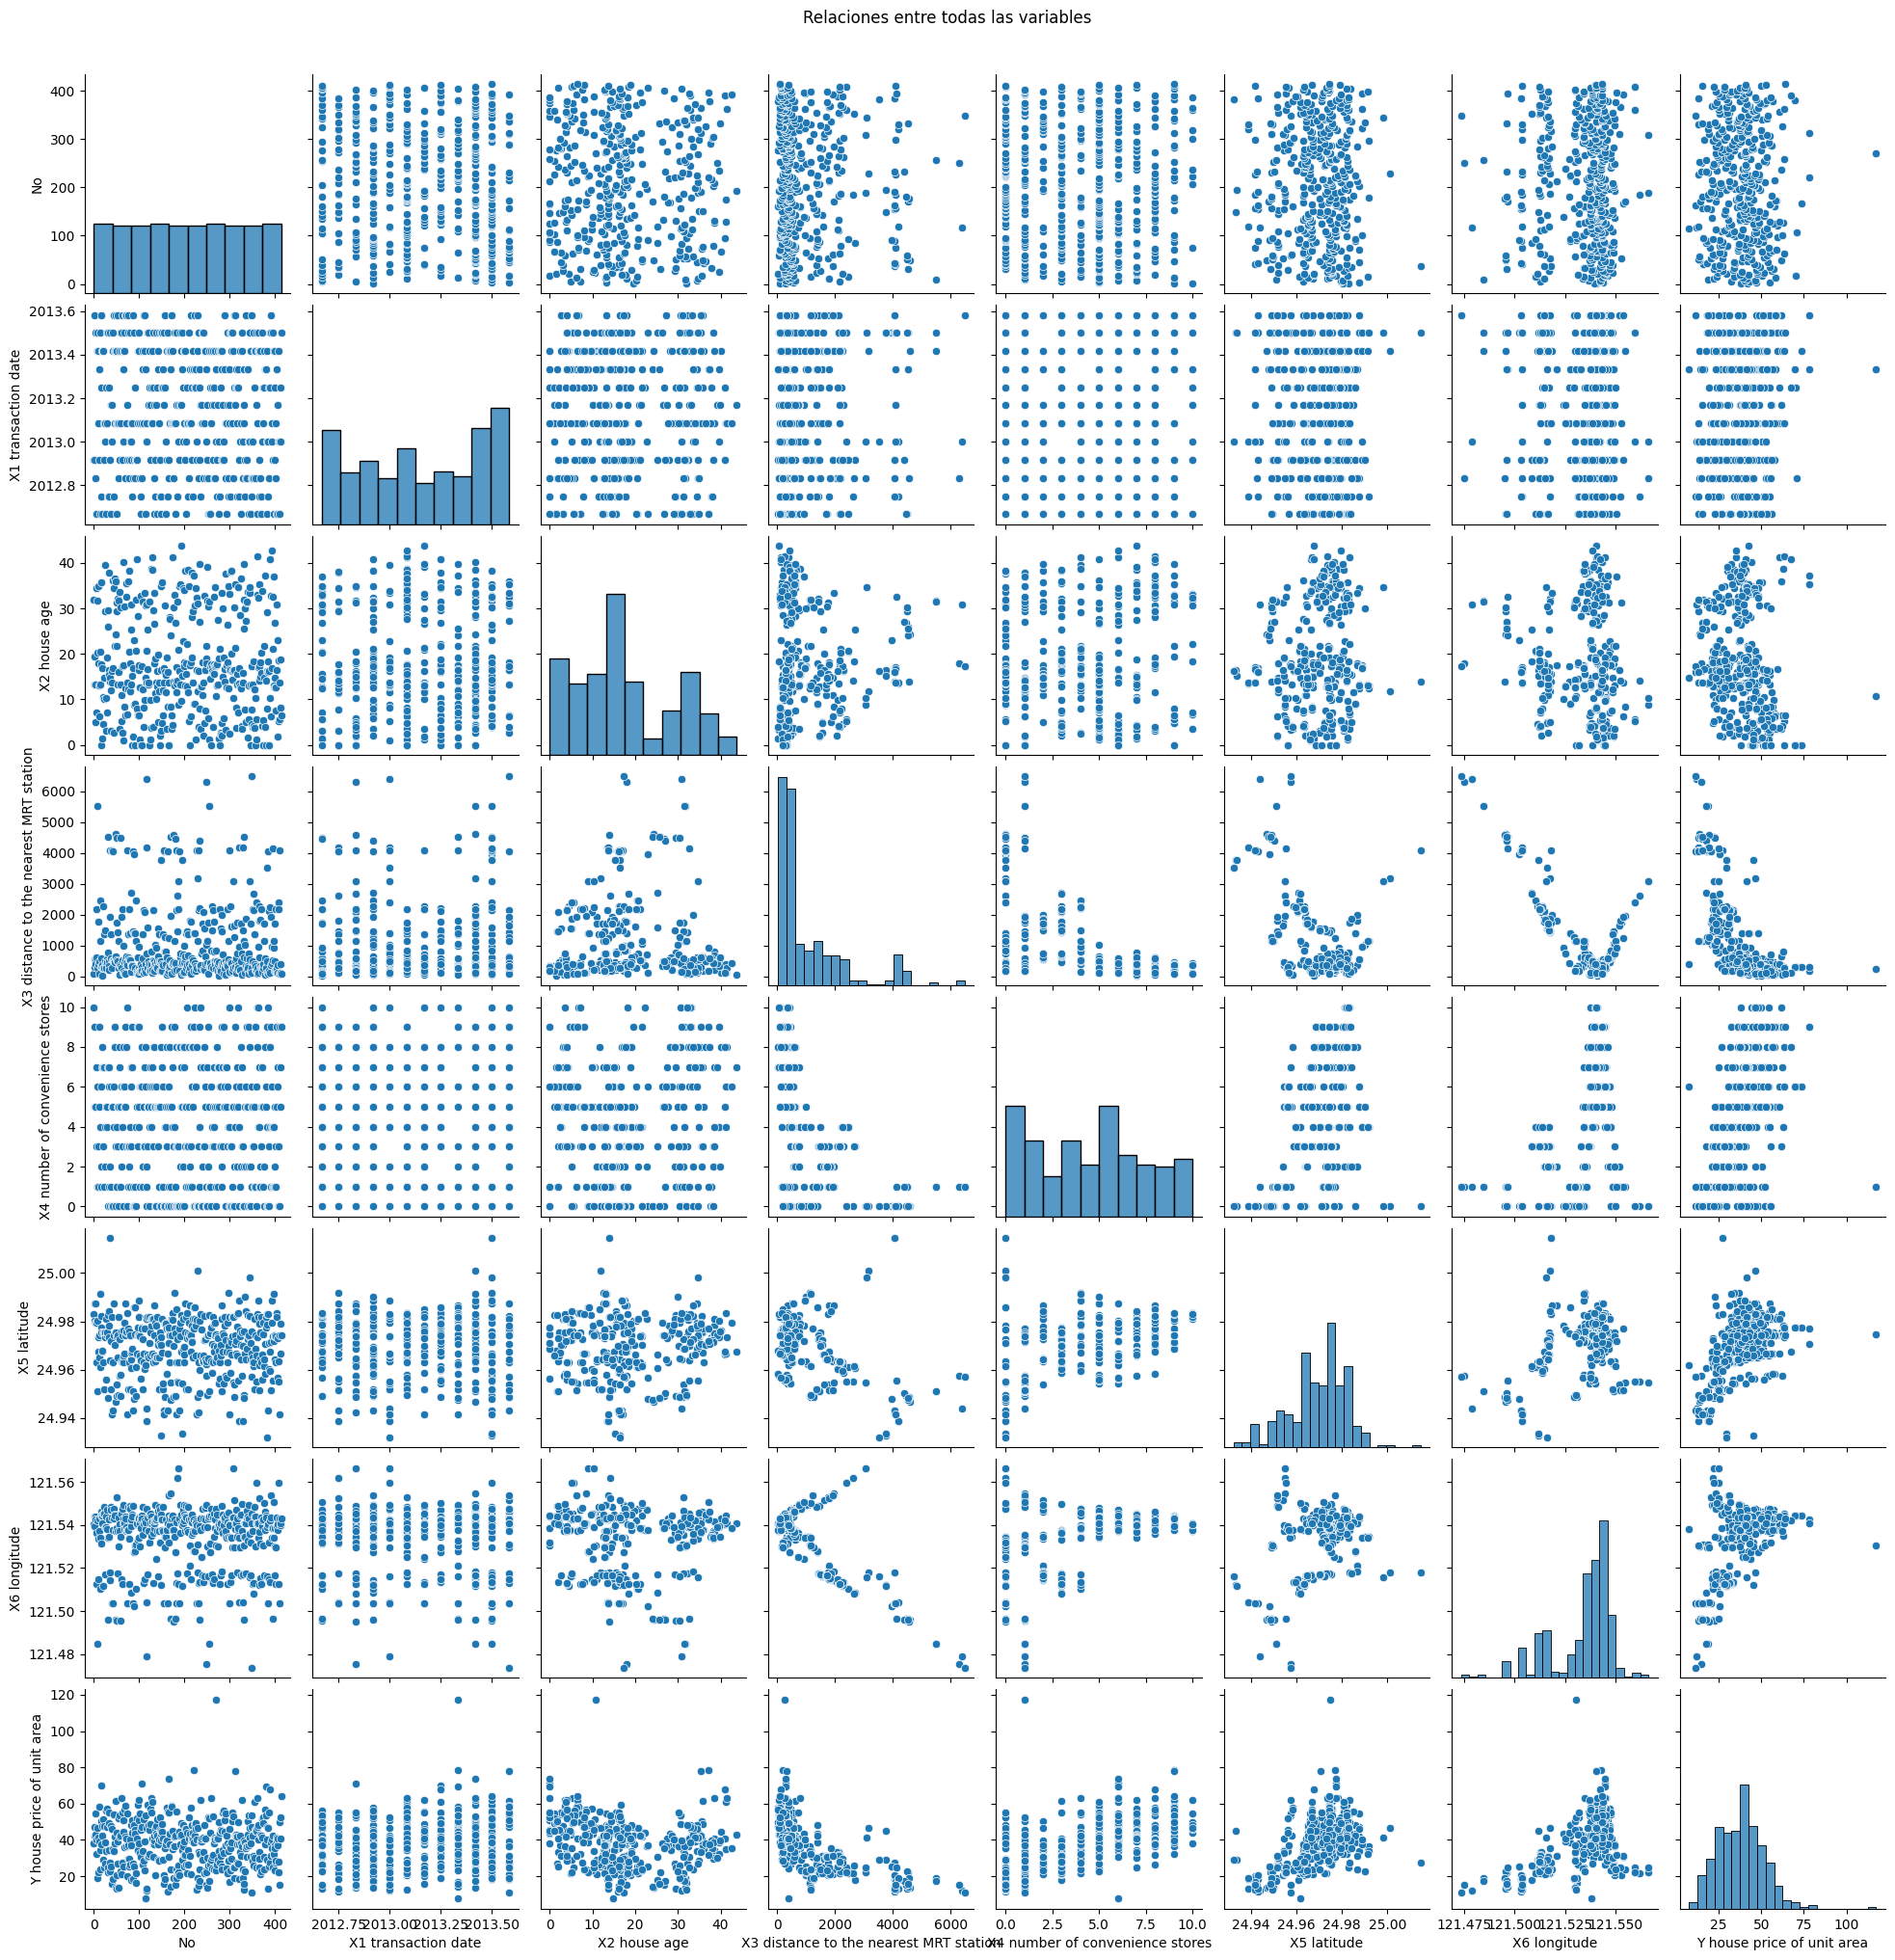

In [20]:
# Pairplot de variables
sns.pairplot(data)
plt.suptitle('Relaciones entre todas las variables', y=1.02)
plt.show()

In [21]:
data.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [22]:
#  Dividir datos en entrenamiento y prueba
X = data.drop('Y house price of unit area', axis=1)
y = data['Y house price of unit area']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")

Tamaño de entrenamiento: 289 muestras
Tamaño de prueba: 125 muestras


In [23]:
# Entrenar modelo de regresión lineal con todas las variables
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
print("=== COEFICIENTES DEL MODELO ===\n")
print(coeficientes)
print(f"\nIntercept (término constante): {modelo.intercept_:.4f}")

=== COEFICIENTES DEL MODELO ===

                                 Variable  Coeficiente
0                                      No    -0.006260
1                     X1 transaction date     5.859783
2                            X2 house age    -0.239516
3  X3 distance to the nearest MRT station    -0.005230
4         X4 number of convenience stores     1.064933
5                             X5 latitude   236.128176
6                            X6 longitude   -54.468708

Intercept (término constante): -11027.8852


In [24]:
# Evaluar modelo completo
y_pred = modelo.predict(X_test)

MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = metrics.r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN ===\n")
print(f"Error Absoluto Medio (MAE): {MAE:.4f}")
print(f"Error Cuadrático Medio (MSE): {MSE:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {RMSE:.4f}")
print(f"R² (Coeficiente de Determinación): {R2:.4f}")

=== MÉTRICAS DE EVALUACIÓN ===

Error Absoluto Medio (MAE): 6.2664
Error Cuadrático Medio (MSE): 74.7087
Raíz del Error Cuadrático Medio (RMSE): 8.6434
R² (Coeficiente de Determinación): 0.5532


### *INTERPRETACIÓN*

El modelo explica un 55% de la variabilidad de los precios de las propiedades. Captura un tendencia importante, pero deja un 44.7% de error sin explicar.

  - MAE (6.2664) : En promedio las predicciones se desvían un 6.2  unidades de precio.

  - RMSE (8.6434) : Al ser mayor que MAE, penaliza más errores grandes, indicando el modelo comete algunos fallos considerablemente altos en ciertas predicciones.

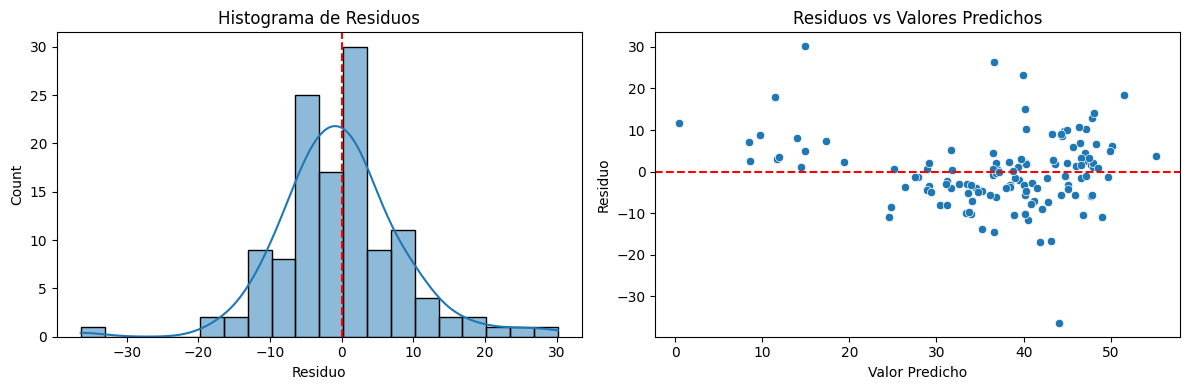

Media de residuos: -0.0900
Desviación estándar de residuos: 8.6777


In [25]:
# Análisis de residuos
residuos = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, bins=20)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Histograma de Residuos')
plt.xlabel('Residuo')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Valores Predichos')
plt.xlabel('Valor Predicho')
plt.ylabel('Residuo')

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")

### *INTERPRETACIÓN*

- Histograma de Residuos:

Tiene una forma medio simétrico cerca del cero, la media de residuos es (-0.09) prácticamnete cero, indica que el modelo **no está sobrestimando o subestimando sistematicamnete** de forma global. Cerca del "-35"  se ve un residuo claro o error bastante grande, un claro ejemplo,  donde el modelo falló por mucho.

- Residuos VS Valores Predichos:

Este sirve para comprobar homocedasidad (si la varianza de erorres es constante) y la linealidad del modelo.
*-Dispersión:* los puntos están distribuidos de manera relativamente aleatoria alrededor de la línea puntuada "y=0"; esto es una buena señal de que la varianza de los errores es más o menos constante.
*-Concentración:* La mayor cantidad de predicciones se agrupa en el rango central-alto (entre 35 y 50 de valor predicho). Hacia la izquierda (valores predichos bajos), hay pocos datos y un residuo atípico muy alto (cerca de 30) y otro muy bajo (cerca de -35), lo que muestra que el modelo es menos preciso o tiene menos información en esa zona de valores bajos.


In [26]:
# Cálculo del VIF (Factor de Inflación de la Varianza)
X_constant = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_constant.values, i)
                   for i in range(X_constant.shape[1])]

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===\n")
print(vif_data)
print("\n Recuerda:")
print("- VIF > 5: indica alta multicolinealidad")
print("- VIF > 10: indica multicolinealidad severa")

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===

                                 Variable       VIF
0                                   const  1.000000
1                                      No  1.005872
2                     X1 transaction date  1.016623
3                            X2 house age  1.015215
4  X3 distance to the nearest MRT station  4.332646
5         X4 number of convenience stores  1.617793
6                             X5 latitude  1.610771
7                            X6 longitude  2.931428

 Recuerda:
- VIF > 5: indica alta multicolinealidad
- VIF > 10: indica multicolinealidad severa


In [27]:
#  Selección hacia adelante (Forward Selection)
def forward_selection(X, y, threshold=0.05):
    """
    Selección de variables hacia adelante basada en p-valor
    """
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)

        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]

        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

        if not changed:
            break

    return included

print("=== SELECCIÓN HACIA ADELANTE ===\n")
variables_seleccionadas = forward_selection(X, y)
print(f"Variables seleccionadas: {variables_seleccionadas}")

=== SELECCIÓN HACIA ADELANTE ===

Variables seleccionadas: ['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude', 'X1 transaction date']


In [28]:
# Comparación de modelos con diferentes variables
print("=== COMPARACIÓN DE MODELOS ===\n")

combinaciones = [
    # Modelo 1: Solo la variable que entró primero
    ['X3 distance to the nearest MRT station'],

    # Modelo 2: Tres variables principales
    [
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X2 house age'
    ],

    # Modelo 3: Se agrega latitud
    [
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X2 house age',
        'X5 latitude'
    ],

    # Modelo 4: Variables seleccionadas por Forward Selection
    variables_seleccionadas,

    # Modelo 5: Todas las variables explicativas
    [
        'X1 transaction date',
        'X2 house age',
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X5 latitude',
        'X6 longitude'
    ]
]

nombres_combinaciones = [
    'Modelo 1: Solo X3',
    'Modelo 2: X3 + X4 + X2',
    'Modelo 3: X3 + X4 + X2 + X5',
    'Modelo 4: Variables seleccionadas (Forward)',
    'Modelo 5: Modelo completo'
]

for nombre, vars_list in zip(nombres_combinaciones, combinaciones):

    X_sel = sm.add_constant(X[vars_list])
    model = sm.OLS(y, X_sel).fit()

    print(f"📊 {nombre}")
    print(f"  Variables: {vars_list}")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  R² ajustado = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  BIC = {model.bic:.2f}")
    print()

=== COMPARACIÓN DE MODELOS ===

📊 Modelo 1: Solo X3
  Variables: ['X3 distance to the nearest MRT station']
  R² = 0.4538
  R² ajustado = 0.4524
  AIC = 3089.07
  BIC = 3097.12

📊 Modelo 2: X3 + X4 + X2
  Variables: ['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age']
  R² = 0.5411
  R² ajustado = 0.5377
  AIC = 3020.97
  BIC = 3037.08

📊 Modelo 3: X3 + X4 + X2 + X5
  Variables: ['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude']
  R² = 0.5711
  R² ajustado = 0.5669
  AIC = 2994.91
  BIC = 3015.04

📊 Modelo 4: Variables seleccionadas (Forward)
  Variables: ['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude', 'X1 transaction date']
  R² = 0.5823
  R² ajustado = 0.5772
  AIC = 2985.99
  BIC = 3010.15

📊 Modelo 5: Modelo completo
  Variables: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of 

In [29]:
# Análisis detallado del mejor modelo
print("=== MEJOR MODELO SEGÚN FORWARD SELECTION ===\n")

X_sel = sm.add_constant(X[variables_seleccionadas])
modelo_final = sm.OLS(y, X_sel).fit()
print(modelo_final.summary())

=== MEJOR MODELO SEGÚN FORWARD SELECTION ===

                                OLS Regression Results                                
Dep. Variable:     Y house price of unit area   R-squared:                       0.582
Model:                                    OLS   Adj. R-squared:                  0.577
Method:                         Least Squares   F-statistic:                     113.8
Date:                        Thu, 17 Sep 2026   Prob (F-statistic):           4.47e-75
Time:                                14:47:19   Log-Likelihood:                -1487.0
No. Observations:                         414   AIC:                             2986.
Df Residuals:                             408   BIC:                             3010.
Df Model:                                   5                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|  

In [30]:
# Evaluación del mejor modelo en test
X_train_sel = X_train[variables_seleccionadas]
X_test_sel = X_test[variables_seleccionadas]

modelo_sel = LinearRegression()
modelo_sel.fit(X_train_sel, y_train)

y_pred_sel = modelo_sel.predict(X_test_sel)

MAE_sel = metrics.mean_absolute_error(y_test, y_pred_sel)
MSE_sel = metrics.mean_squared_error(y_test, y_pred_sel)
RMSE_sel = np.sqrt(MSE_sel)
R2_sel = metrics.r2_score(y_test, y_pred_sel)

print("=== COMPARACIÓN DE RENDIMIENTO ===\n")
print("Modelo Completo vs Modelo Seleccionado:")

print(f"\nModelo Completo (todas las variables):")
print(f"  MAE: {MAE:.4f}")
print(f"  RMSE: {RMSE:.4f}")
print(f"  R²: {R2:.4f}")

print(f"\nModelo Seleccionado ({variables_seleccionadas}):")
print(f"  MAE: {MAE_sel:.4f}")
print(f"  RMSE: {RMSE_sel:.4f}")
print(f"  R²: {R2_sel:.4f}")

=== COMPARACIÓN DE RENDIMIENTO ===

Modelo Completo vs Modelo Seleccionado:

Modelo Completo (todas las variables):
  MAE: 6.2664
  RMSE: 8.6434
  R²: 0.5532

Modelo Seleccionado (['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude', 'X1 transaction date']):
  MAE: 6.1424
  RMSE: 8.5266
  R²: 0.5652


###*Interpretación*
Al comparar los diferentes modelos se observa que el desempeño mejora conforme se incorporan las variables seleccionadas mediante el método Forward Selection. El modelo con cinco variables alcanzó un R² de 0.5823 y un R² ajustado de 0.5772. Al agregar la variable X6 longitude, el R² únicamente aumentó a 0.5824, mientras que el R² ajustado disminuyó a 0.5762. Además, el modelo seleccionado presentó valores menores de AIC y BIC. En los datos de prueba también obtuvo un menor MAE y RMSE y un mayor R². Por lo tanto, el modelo obtenido mediante Forward Selection ofrece un mejor equilibrio entre capacidad predictiva y simplicidad, ya que eliminar X6 longitude no produce una pérdida significativa de información.

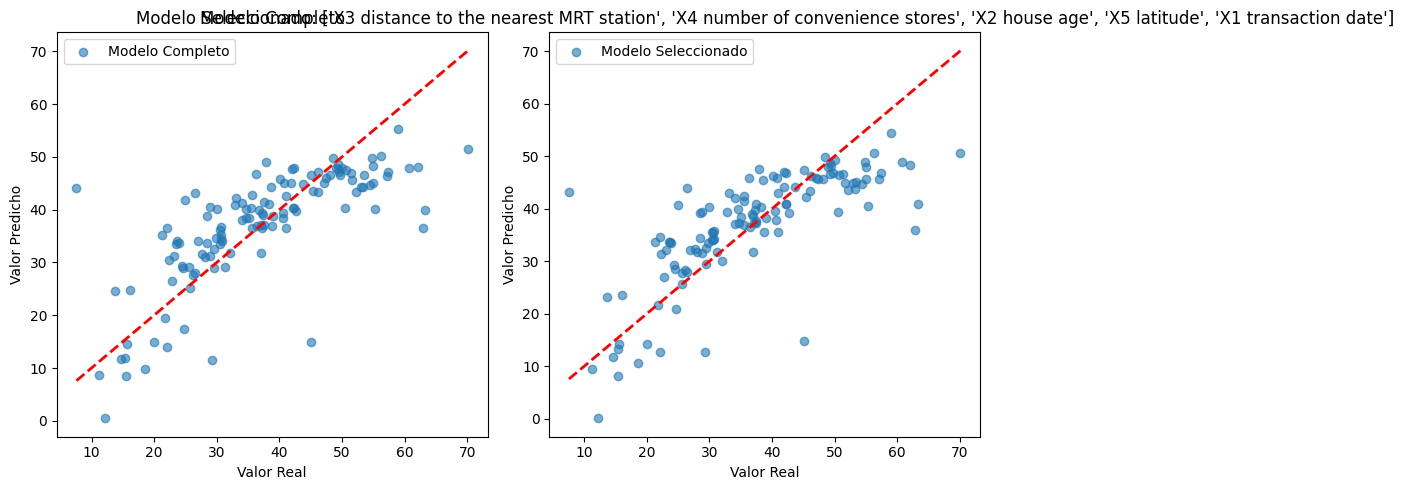

In [31]:
# Visualización del modelo seleccionado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, label='Modelo Completo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Modelo Completo')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sel, alpha=0.6, label='Modelo Seleccionado')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title(f'Modelo Seleccionado: {variables_seleccionadas}')
plt.legend()

plt.tight_layout()
plt.show()

Los gráficos muestran que ambos modelos presentan un comportamiento muy similar, ya que sus predicciones se concentran alrededor de la línea ideal. El modelo seleccionado mediante Forward Selection mantiene una capacidad predictiva comparable al modelo completo utilizando una variable menos, lo que permite obtener un modelo más simple sin una pérdida relevante de rendimiento.